## Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Obtener datos de archivo

In [2]:
df = pd.read_excel('../data/stats_test_2.xlsx')
df.head()

,TIEMPO (seg),PUNTAJE (pts),EXITO (%),"GRAVEDAD (-15, 0)","PODER VIENTO (0, 20)"
0,5.89,-4.24,33.33,-5.0,0.4
1,7.00,-500.29,33.33,-3.0,0.4
2,29.19,-924.64,0.00,-1.0,0.4
3,7.99,-1526.27,0.00,0.5,0.4
4,5.86,-467.75,0.00,-5.0,0.4


## Limpiar datos

In [4]:
# Clean columns by removing non-standard minus signs, replacing commas with dots, and converting to float
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('−', '-').str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows that couldn't be parsed properly (if any)
df = df.dropna()

# Rename columns slightly for cleaner axis labels
df.columns = [col.strip() for col in df.columns]
df.columns

Index(['TIEMPO (seg)', 'PUNTAJE (pts)', 'EXITO (%)', 'GRAVEDAD (-15, 0)',
       'PODER VIENTO (0, 20)'],
      dtype='object')

## Ajustes de gráficos estadísticos

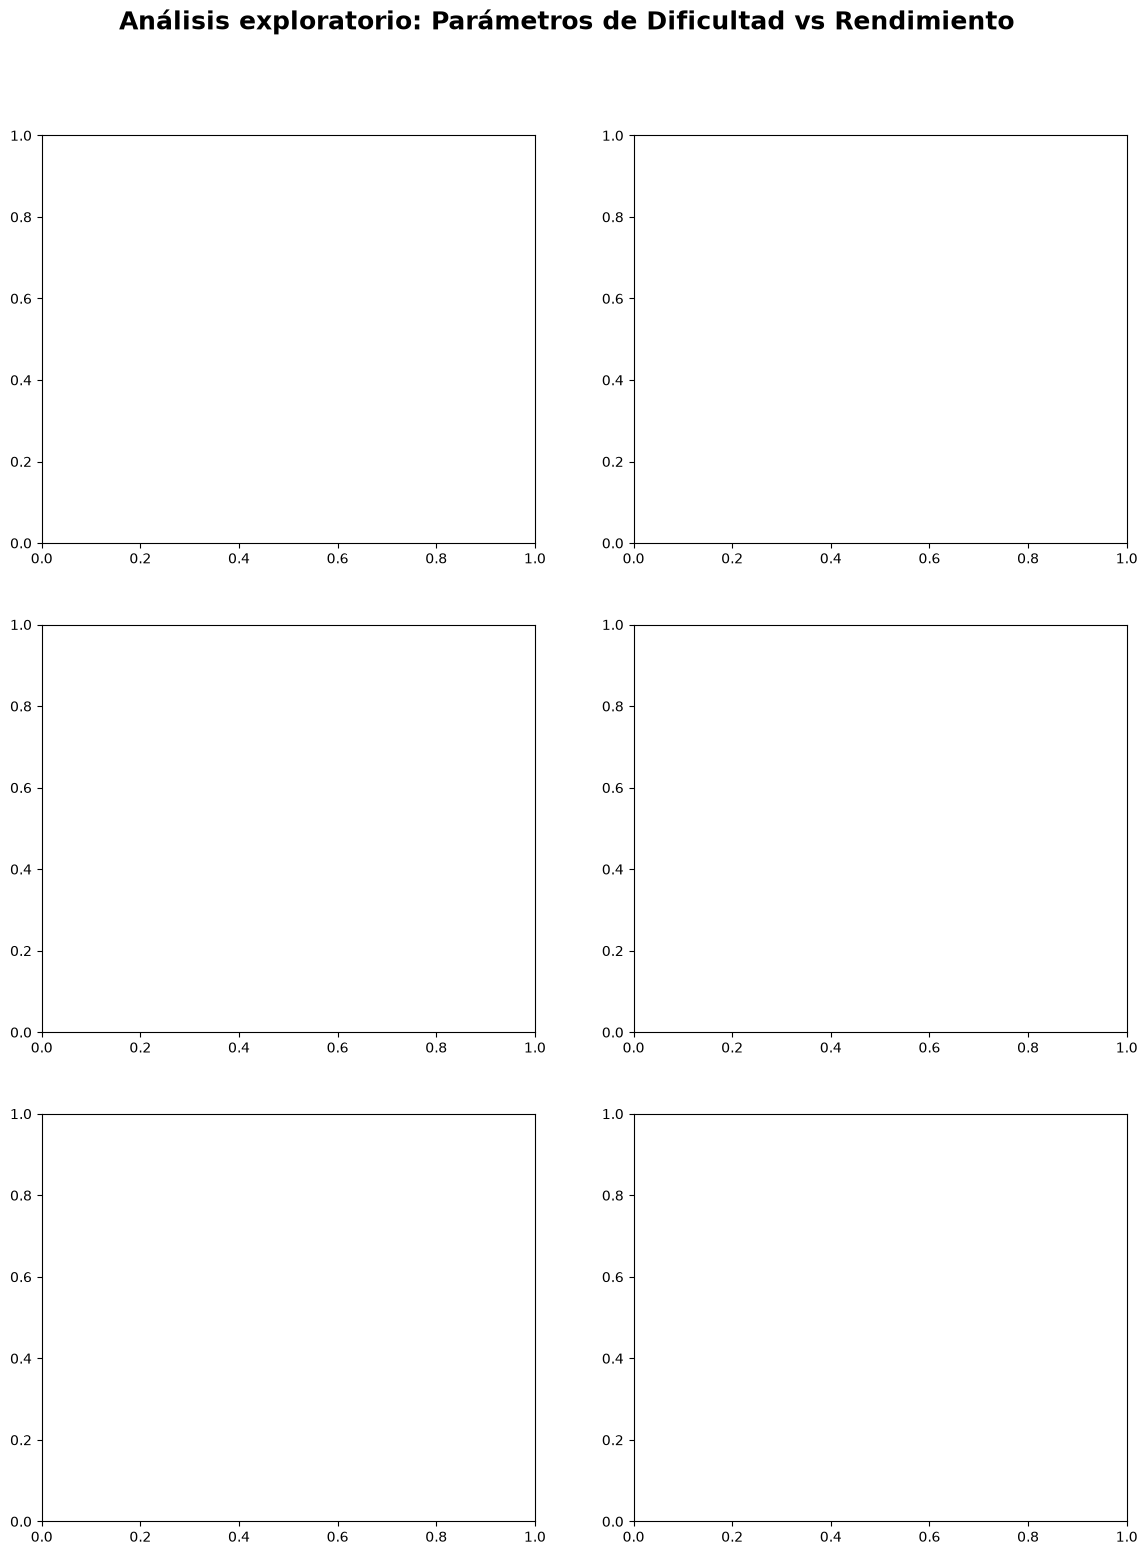

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Análisis exploratorio: Parámetros de Dificultad vs Rendimiento', fontsize=18, fontweight='bold', y=0.95)

# Define our Independent (X) and Dependent (Y) variables based on your request
relationships = [
    ('GRAVEDAD (-15, 0)', 'PUNTAJE (pts)', axes[0, 0], 'teal'),
    ('PODER VIENTO (0, 20)', 'PUNTAJE (pts)', axes[0, 1], 'coral'),
    ('GRAVEDAD (-15, 0)', 'TIEMPO (seg)', axes[1, 0], 'purple'),
    ('PODER VIENTO (0, 20)', 'TIEMPO (seg)', axes[1, 1], 'gold'),
    ('GRAVEDAD (-15, 0)', 'EXITO (%)', axes[2, 0], 'green'),
    ('PODER VIENTO (0, 20)', 'EXITO (%)', axes[2, 1], 'darkblue')
]

## Generación de gráficos

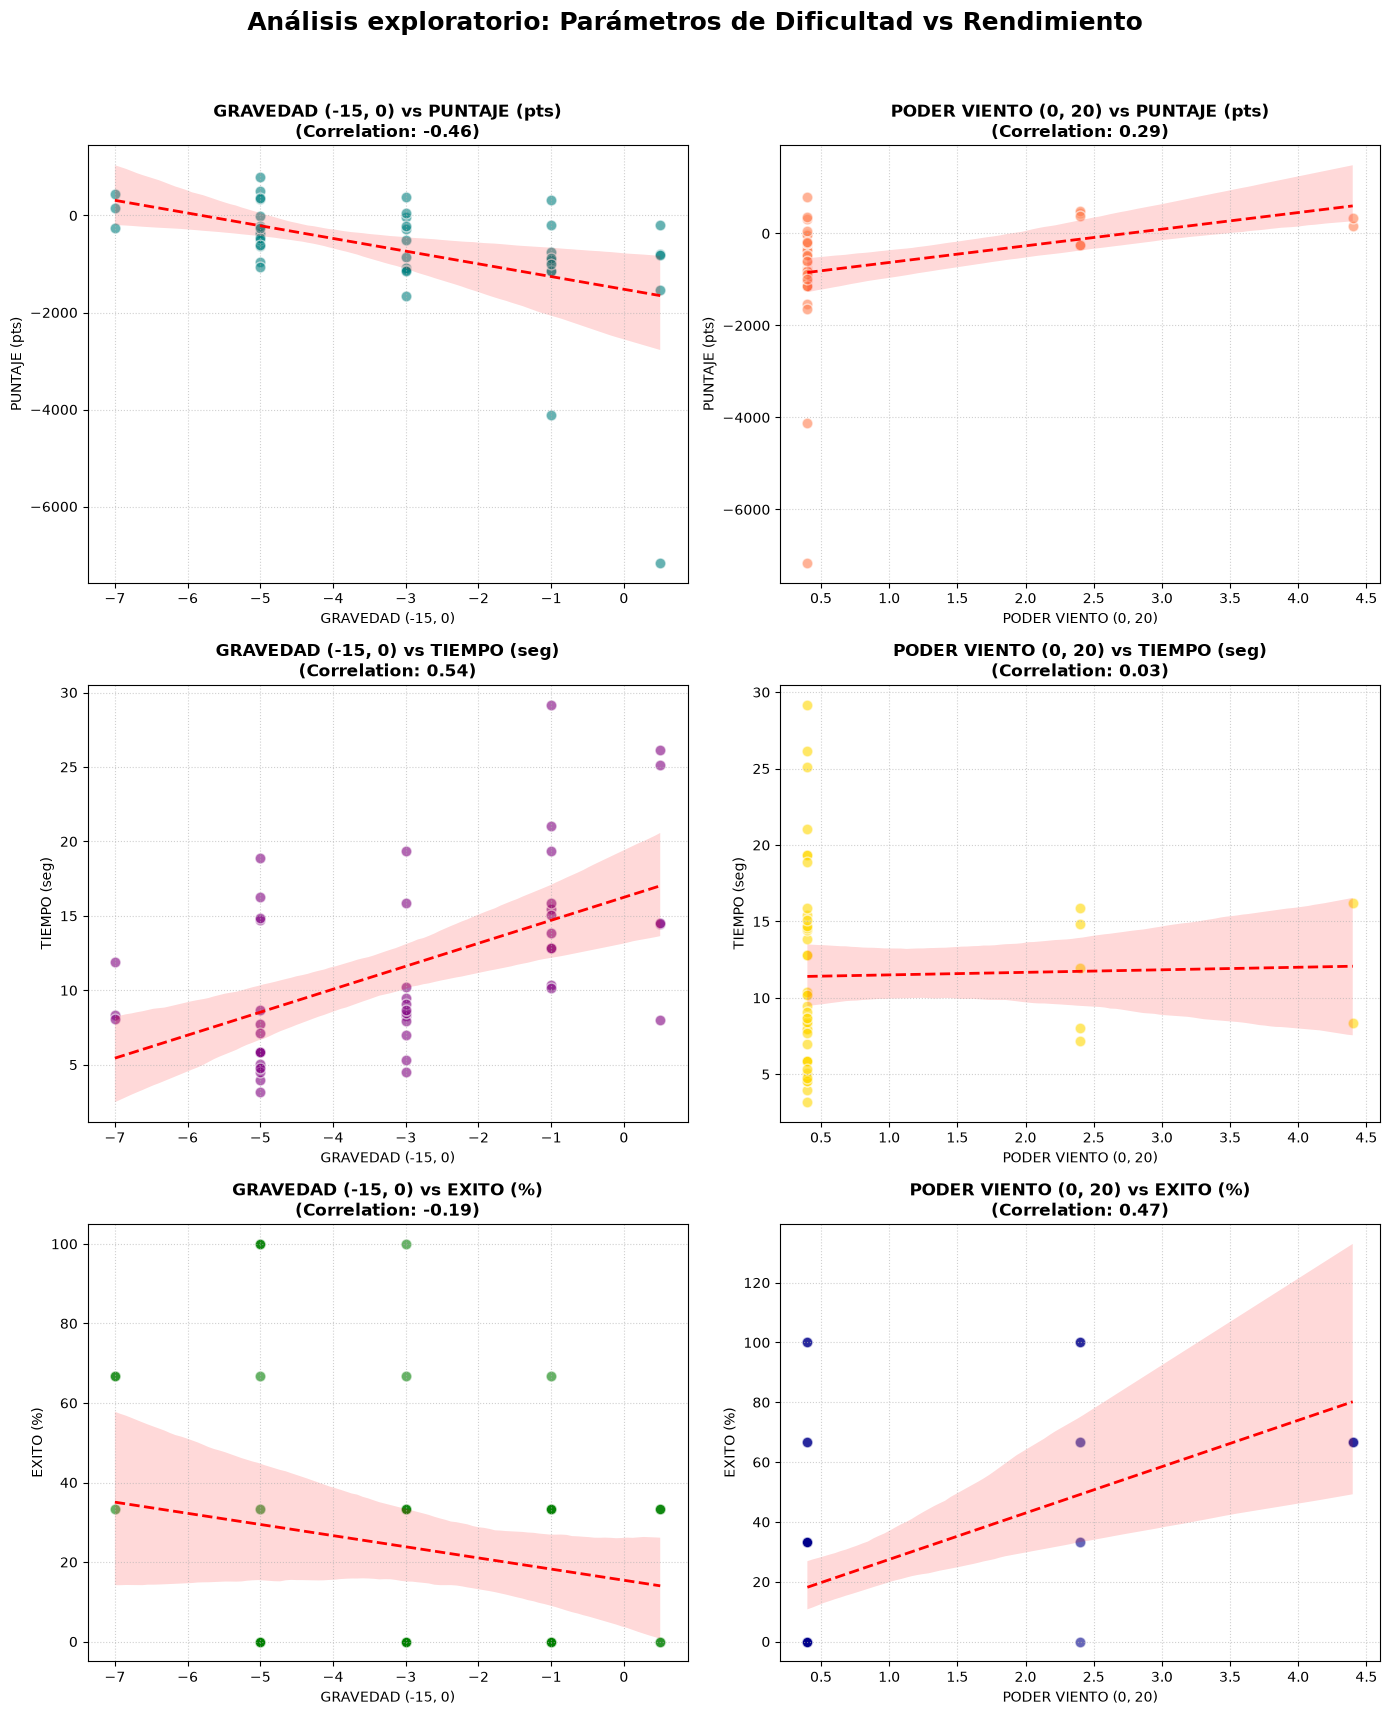

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Análisis exploratorio: Parámetros de Dificultad vs Rendimiento', fontsize=18, fontweight='bold', y=0.95)

# Define our Independent (X) and Dependent (Y) variables based on your request
relationships = [
    ('GRAVEDAD (-15, 0)', 'PUNTAJE (pts)', axes[0, 0], 'teal'),
    ('PODER VIENTO (0, 20)', 'PUNTAJE (pts)', axes[0, 1], 'coral'),
    ('GRAVEDAD (-15, 0)', 'TIEMPO (seg)', axes[1, 0], 'purple'),
    ('PODER VIENTO (0, 20)', 'TIEMPO (seg)', axes[1, 1], 'gold'),
    ('GRAVEDAD (-15, 0)', 'EXITO (%)', axes[2, 0], 'green'),
    ('PODER VIENTO (0, 20)', 'EXITO (%)', axes[2, 1], 'darkblue')
]

for x_col, y_col, ax, color in relationships:
    # Use a scatter plot with a trendline (regplot) to show the "progress" / relationship
    # ax.scatter(df[x_col], df[y_col])
    sns.regplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        ax=ax, 
        color=color, 
        scatter_kws={'alpha':0.6, 'edgecolor':'w', 's':60},
        line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'}
    )
    
    # Calculate Pearson correlation to display on the plot
    correlation = df[x_col].corr(df[y_col])
    
    # Formatting
    ax.set_title(f'{x_col} vs {y_col}\n(Correlation: {correlation:.2f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

# Adjust layout so labels don't overlap
plt.tight_layout(rect=[0, 0, 1, 0.93])

# 6. Optional: Print a quick statistical summary matrix
# print("--- Correlation Matrix ---")
# print(df.corr())

# Display the dashboard
plt.show()

<Axes: >

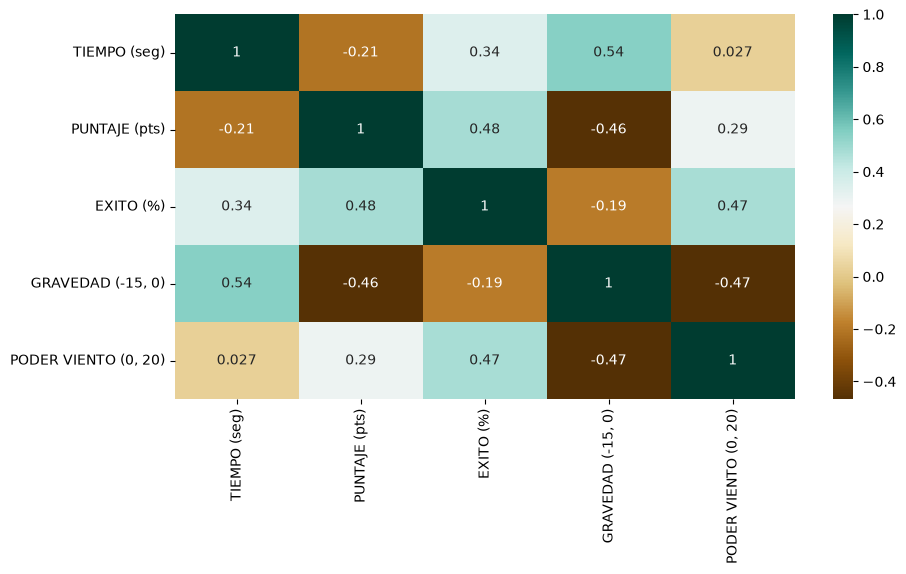

In [12]:
plt.figure(figsize=(10,5))
c= df.corr()
sns.heatmap(c,cmap="BrBG",annot=True)